In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
%matplotlib inline

In [2]:
filename = 'diabetes_dataset.csv'
df = pd.read_csv(filename)
df.head(1)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1


In [3]:
df.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

In [4]:
df['diabetes_stage'].value_counts()

diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64

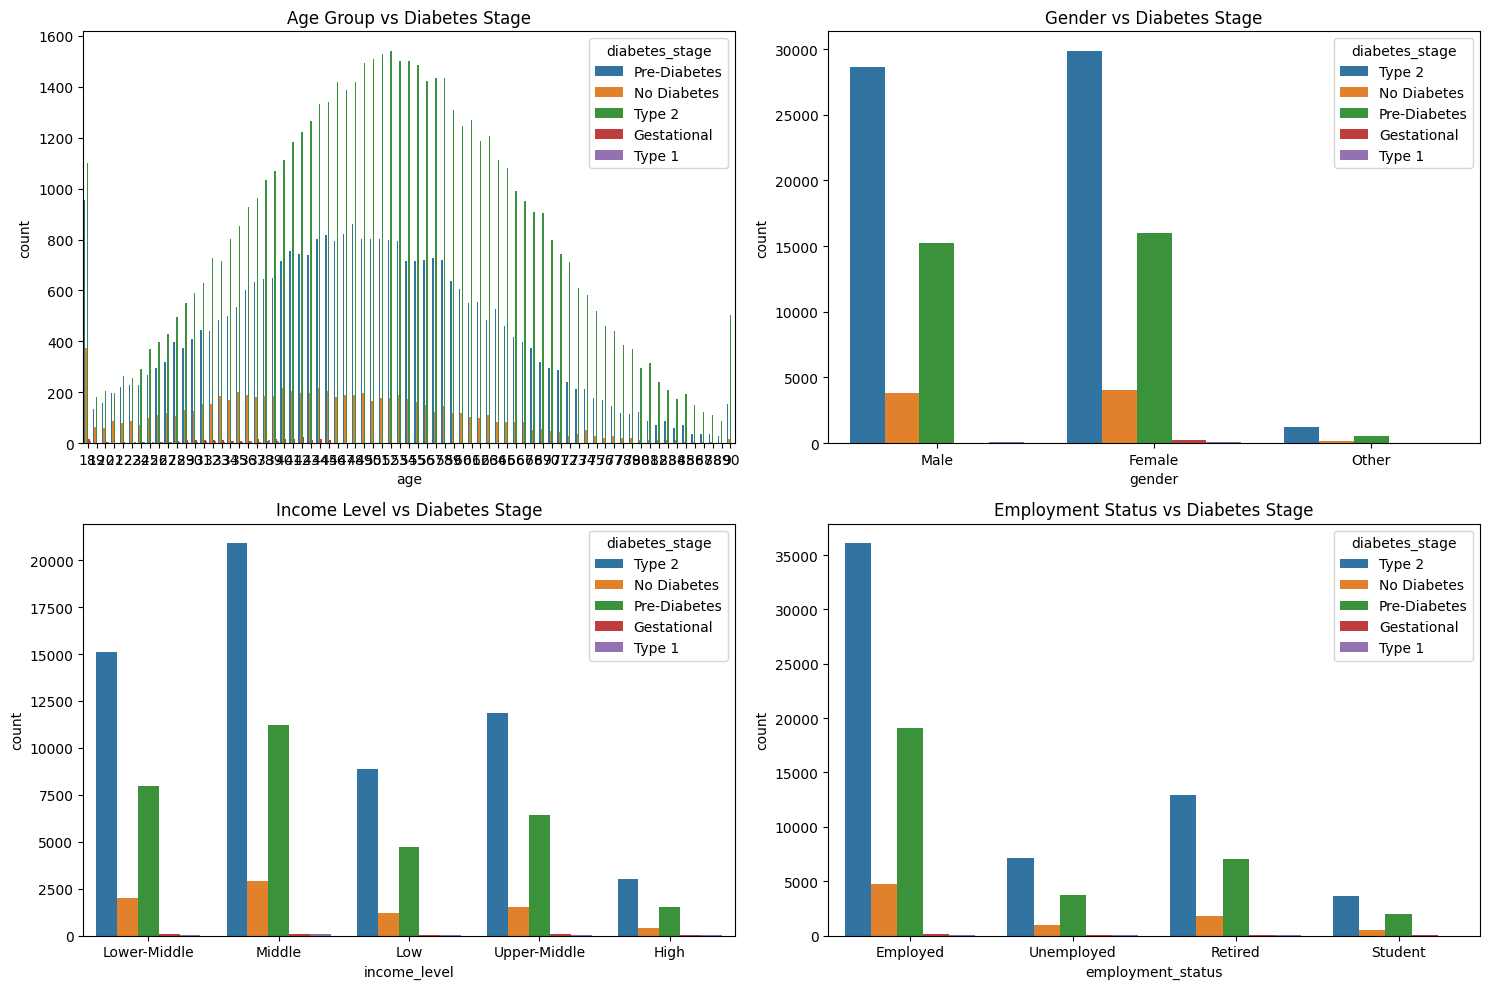

In [5]:
# age , gender, income level , employment status count plots
fig, axes = plt.subplots(2, 2, figsize=(15,10))
sns.countplot(ax=axes[0,0], data=df, x='age', hue='diabetes_stage')
axes[0,0].set_title('Age Group vs Diabetes Stage')
sns.countplot(ax=axes[0,1], data=df, x='gender', hue='diabetes_stage')
axes[0,1].set_title('Gender vs Diabetes Stage')
sns.countplot(ax=axes[1,0], data=df, x='income_level', hue='diabetes_stage')
axes[1,0].set_title('Income Level vs Diabetes Stage')
sns.countplot(ax=axes[1,1], data=df, x='employment_status', hue='diabetes_stage')
axes[1,1].set_title('Employment Status vs Diabetes Stage')
plt.tight_layout()
plt.show()

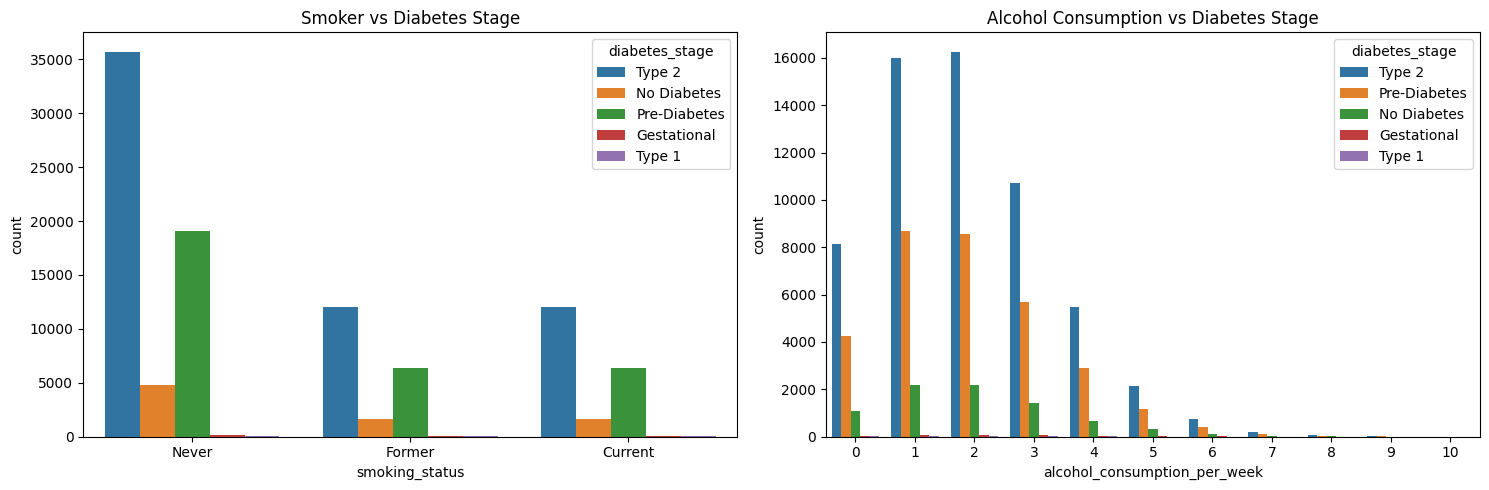

In [9]:
# smoker and alcohol consumption diabetes stage
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.countplot(ax=axes[0], data=df, x='smoking_status', hue='diabetes_stage')
axes[0].set_title('Smoker vs Diabetes Stage')
sns.countplot(ax=axes[1], data=df, x='alcohol_consumption_per_week', hue='diabetes_stage')
axes[1].set_title('Alcohol Consumption vs Diabetes Stage')
plt.tight_layout()
plt.show()

In [10]:
df.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

In [11]:
# sleep hours vs screen tim hours by diabetes diagnosis
fig = px.scatter(df,
                x = 'sleep_hours_per_day',
                y = 'screen_time_hours_per_day',
                color = 'diagnosed_diabetes',
                title = 'Sleep Hours vs Screen Time Hours by Diabetes Diagnosis')
fig.show()

In [14]:
# physical activity minutes per week vc diet score
fig = px.scatter(df.sample(n=2000, random_state=42),
                x = 'physical_activity_minutes_per_week',
                y = 'diet_score',
                color = 'diagnosed_diabetes',
                title = 'Physical Activity Minutes per Week vs BMI by Diabetes Diagnosis')
fig.show()

In [15]:
gender_diabetes = df.groupby('gender')['diagnosed_diabetes'].sum().reset_index()
gender_diabetes

,gender,diagnosed_diabetes
0,Female,30052
1,Male,28694
2,Other,1252


In [19]:
df['pampw_diet_score_ratio'] = df['physical_activity_minutes_per_week'] / df['diet_score']
df[['physical_activity_minutes_per_week', 'diet_score', 'pampw_diet_score_ratio']].head()

,physical_activity_minutes_per_week,diet_score,pampw_diet_score_ratio
0,215,5.7,37.719298
1,143,6.7,21.343284
2,57,6.4,8.906250
3,49,3.4,14.411765
4,109,7.2,15.138889


In [21]:
fig = px.scatter(df.sample(n=2000, random_state=42),
                x = 'pampw_diet_score_ratio',
                y = 'diagnosed_diabetes',
                title = 'Physical Activity Minutes per Week to Diet Score Ratio vs Diabetes Diagnosis')
fig.show()

In [22]:
# systolic bp vs diastolic bp by diabetes diagnosis
fig = px.scatter(df.sample(n=2000, random_state=42),
                x = 'systolic_bp',
                y = 'diastolic_bp',
                color = 'diagnosed_diabetes',
                title = 'Systolic BP vs Diastolic BP by Diabetes Diagnosis')
fig.show()

In [23]:
df['systolic_diastolic_ratio'] = df['systolic_bp'] / df['diastolic_bp']
df[['systolic_bp', 'diastolic_bp', 'systolic_diastolic_ratio']].head()

,systolic_bp,diastolic_bp,systolic_diastolic_ratio
0,134,78,1.717949
1,129,76,1.697368
2,115,73,1.575342
3,120,93,1.290323
4,92,67,1.373134


In [39]:
fig = px.scatter(df.sample(n=2000),
                x = 'systolic_diastolic_ratio',
                y = 'diagnosed_diabetes',
                title = 'Systolic to Diastolic BP Ratio vs Diabetes Diagnosis')
fig.show()

In [41]:
# hdl cholesterol vs ldl cholesterol 
fig = px.scatter(df.sample(n=2000, random_state=42),
                x = 'hdl_cholesterol',
                y = 'ldl_cholesterol',
                color = 'diagnosed_diabetes',
                title = 'HDL Cholesterol vs LDL Cholesterol by Diabetes Diagnosis')
fig.show()

In [42]:
df['hdl_ldl_ratio'] = df['hdl_cholesterol'] / df['ldl_cholesterol']
df[['hdl_cholesterol', 'ldl_cholesterol', 'hdl_ldl_ratio']].head()

,hdl_cholesterol,ldl_cholesterol,hdl_ldl_ratio
0,41,160,0.256250
1,55,50,1.100000
2,66,99,0.666667
3,50,79,0.632911
4,52,125,0.416000


In [52]:
fig = px.scatter(df.sample(n=200),
                x = 'hdl_ldl_ratio',
                y = 'diagnosed_diabetes',
                title = 'HDL to LDL Cholesterol Ratio vs Diabetes Diagnosis')
fig.show()

In [65]:
fig = px.scatter(df.sample(n=200),
                x = 'cholesterol_total',
                y = 'diagnosed_diabetes',
                title = 'Total Cholesterol vs Diabetes Diagnosis')
fig.show()

In [68]:
df['glucose_after_eating_to_fasting_ratio'] = df['glucose_postprandial'] / df['glucose_fasting']
df[['glucose_fasting', 'glucose_postprandial', 'glucose_after_eating_to_fasting_ratio']].head()

,glucose_fasting,glucose_postprandial,glucose_after_eating_to_fasting_ratio
0,136,236,1.735294
1,93,150,1.612903
2,118,195,1.652542
3,139,253,1.820144
4,137,184,1.343066


In [78]:
fig = px.scatter(df.sample(n=200),
                 x = 'glucose_after_eating_to_fasting_ratio',
                y = 'diagnosed_diabetes',
                title = 'Glucose After Eating to Fasting Ratio vs Diabetes Diagnosis')
fig.show()

In [96]:
fig = px.scatter(df.sample(n=200),
                x = 'triglycerides',
                y = 'diagnosed_diabetes',
                title = 'Triglycerides vs Diabetes Diagnosis')
fig.show()

In [105]:
fig = px.scatter(df.sample(200),
                x = 'insulin_level',
                y = 'diagnosed_diabetes',
                title = 'Insulin Level vs Diabetes Diagnosis')
fig.show()

In [133]:
fig = px.scatter(df.sample(200),
                x = 'hba1c',
                y = 'diagnosed_diabetes',
                title = 'HbA1c vs Diabetes Diagnosis')
fig.show()

In [136]:
df ['bmi_to_age_ratio'] = df['bmi'] / df['age']
df [['bmi', 'age', 'bmi_to_age_ratio']].head()

,bmi,age,bmi_to_age_ratio
0,30.5,58,0.525862
1,23.1,48,0.481250
2,22.2,60,0.370000
3,26.8,74,0.362162
4,21.2,46,0.460870


In [153]:
fig = px.scatter(df.sample(200),
                x = 'bmi_to_age_ratio',
                y= 'diagnosed_diabetes',
                title='BMI to Age Ratio vs Diabetes Diagnosis')
fig.show()

In [161]:
df['bmi_cholesterol_ratio'] = df['bmi'] / df['cholesterol_total']
df[['bmi', 'cholesterol_total', 'bmi_cholesterol_ratio']].head()

,bmi,cholesterol_total,bmi_cholesterol_ratio
0,30.5,239,0.127615
1,23.1,116,0.199138
2,22.2,213,0.104225
3,26.8,171,0.156725
4,21.2,210,0.100952


In [195]:
fig = px.scatter(df.sample(200),
                x = 'bmi_cholesterol_ratio',
                y = 'diagnosed_diabetes',
                title='BMI to Total Cholesterol Ratio vs Diabetes Diagnosis')
fig.show()

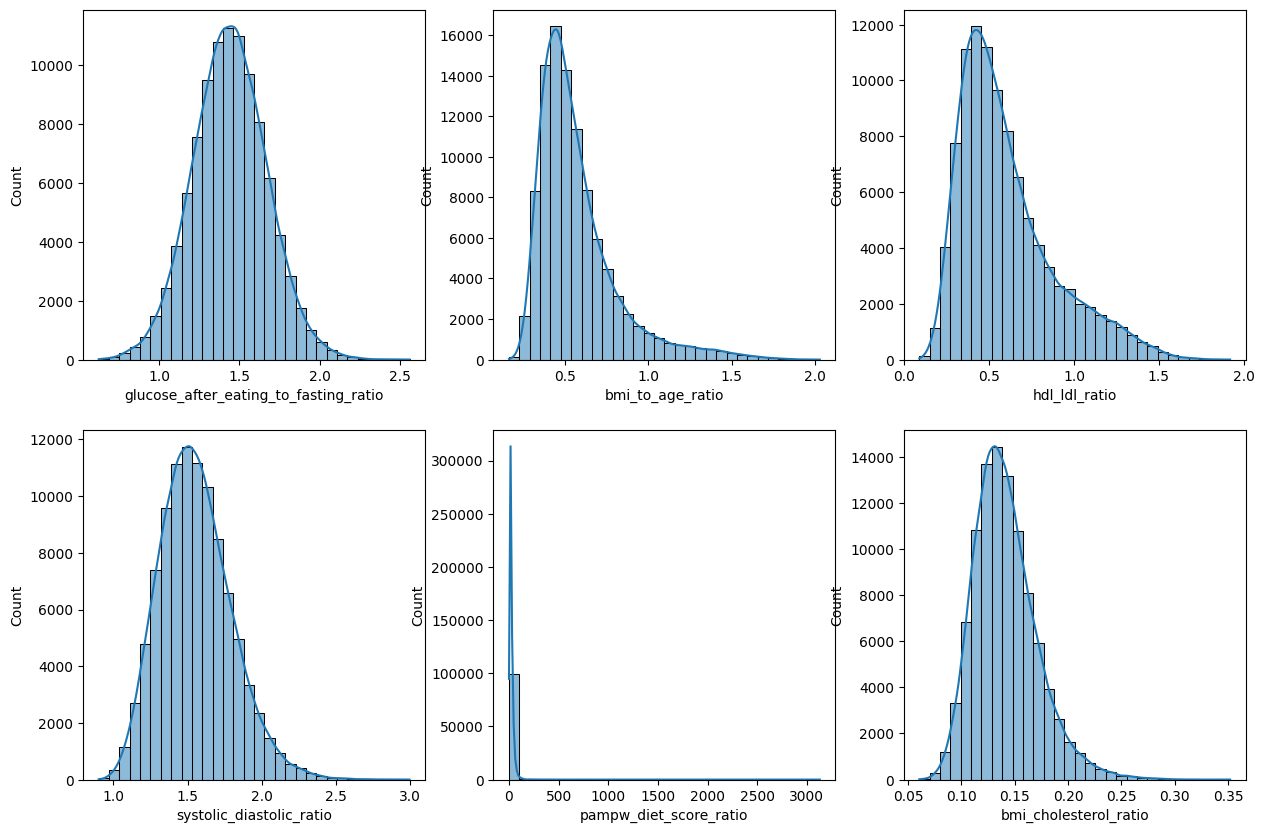

In [196]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))
sns.histplot(ax=axes[0, 0], data=df, x='glucose_after_eating_to_fasting_ratio', bins=30, kde=True)
sns.histplot(ax=axes[0, 1], data=df, x='bmi_to_age_ratio', bins=30, kde=True)
sns.histplot(ax=axes[0, 2], data=df, x='hdl_ldl_ratio', bins=30, kde=True)
sns.histplot(ax=axes[1, 0], data=df, x='systolic_diastolic_ratio', bins=30, kde=True)
sns.histplot(ax=axes[1, 1], data=df, x='pampw_diet_score_ratio', bins=30, kde=True)
sns.histplot(ax=axes[1, 2], data=df, x='bmi_cholesterol_ratio', bins=30, kde=True)
plt.show()


In [197]:
ratio_cols = ['glucose_after_eating_to_fasting_ratio', 'bmi_to_age_ratio',
              'hdl_ldl_ratio', 'systolic_diastolic_ratio', 'pampw_diet_score_ratio','bmi_cholesterol_ratio']
df[ratio_cols].describe()

C:\Users\KUSHANKUR\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning:

invalid value encountered in subtract



,glucose_after_eating_to_fasting_ratio,bmi_to_age_ratio,hdl_ldl_ratio,systolic_diastolic_ratio,pampw_diet_score_ratio,bmi_cholesterol_ratio
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000
mean,1.441821,0.573852,0.601991,1.555273,inf,0.141448
std,0.230507,0.240543,0.280853,0.242385,NaN,0.029918
min,0.625000,0.166667,0.088496,0.900000,0.000000e+00,0.060456
25%,1.287879,0.414286,0.397727,1.383562,9.444444e+00,0.120705
50%,1.440367,0.511905,0.531915,1.536232,1.707692e+01,0.137755
75%,1.593985,0.658140,0.736842,1.705128,2.892857e+01,0.158065
max,2.558442,2.027778,1.920000,3.000000,inf,0.352000


In [201]:
fig = px.scatter(df.sample(200),
                x = 'hba1c',
                y = 'diabetes_risk_score',
                title='HbA1c vs Diabetes Risk Score')
fig.show()

In [202]:
fig = px.scatter(df.sample(200),
                x = 'cholesterol_total',
                y = 'diabetes_risk_score',
                title='Cholesterol Total vs Diabetes Risk Score')
fig.show()

In [203]:
df.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes', 'pampw_diet_score_ratio',
       'systolic_diastolic_ratio', 'hdl_ldl_ratio',
       'glucose_after_eating_to_fasting_ratio', 'bmi_to_age_ratio',
       'bmi_cholesterol_ratio'],
      dtype='object')

In [207]:
input_cols = ['age', 'gender','smoking_status', 'alcohol_consumption_per_week',
       'sleep_hours_per_day' , 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi','cholesterol_total' , 'triglycerides', 'insulin_level', 'hba1c', 
       'physical_activity_minutes_per_week', 'diet_score',
       'systolic_diastolic_ratio', 'hdl_ldl_ratio',
       'glucose_after_eating_to_fasting_ratio', 'bmi_to_age_ratio',
       'bmi_cholesterol_ratio']

target_col = 'diabetes_stage'

In [208]:
numerical_cols = df[input_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df[input_cols].select_dtypes(include=['object']).columns.tolist()
numerical_cols, cat_cols

(['age',
  'alcohol_consumption_per_week',
  'sleep_hours_per_day',
  'family_history_diabetes',
  'hypertension_history',
  'cardiovascular_history',
  'bmi',
  'cholesterol_total',
  'triglycerides',
  'insulin_level',
  'hba1c',
  'physical_activity_minutes_per_week',
  'diet_score',
  'systolic_diastolic_ratio',
  'hdl_ldl_ratio',
  'glucose_after_eating_to_fasting_ratio',
  'bmi_to_age_ratio',
  'bmi_cholesterol_ratio'],
 ['gender', 'smoking_status'])

In [209]:
df[numerical_cols].describe()

,age,alcohol_consumption_per_week,sleep_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,cholesterol_total,triglycerides,insulin_level,hba1c,physical_activity_minutes_per_week,diet_score,systolic_diastolic_ratio,hdl_ldl_ratio,glucose_after_eating_to_fasting_ratio,bmi_to_age_ratio,bmi_cholesterol_ratio
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,6.997818,0.219410,0.250800,0.079200,25.612653,185.978110,121.462650,9.061242,6.520776,118.911640,5.994787,1.555273,0.601991,1.441821,0.573852,0.141448
std,15.60460,1.417779,1.094622,0.413849,0.433476,0.270052,3.586705,32.013005,43.372619,4.954060,0.813921,84.409662,1.780954,0.242385,0.280853,0.230507,0.240543,0.029918
min,18.00000,0.000000,3.000000,0.000000,0.000000,0.000000,15.000000,100.000000,30.000000,2.000000,4.000000,0.000000,0.000000,0.900000,0.088496,0.625000,0.166667,0.060456
25%,39.00000,1.000000,6.300000,0.000000,0.000000,0.000000,23.200000,164.000000,91.000000,5.090000,5.970000,57.000000,4.800000,1.383562,0.397727,1.287879,0.414286,0.120705
50%,50.00000,2.000000,7.000000,0.000000,0.000000,0.000000,25.600000,186.000000,121.000000,8.790000,6.520000,100.000000,6.000000,1.536232,0.531915,1.440367,0.511905,0.137755
75%,61.00000,3.000000,7.700000,0.000000,1.000000,0.000000,28.000000,208.000000,151.000000,12.450000,7.070000,160.000000,7.200000,1.705128,0.736842,1.593985,0.658140,0.158065
max,90.00000,10.000000,10.000000,1.000000,1.000000,1.000000,39.200000,318.000000,344.000000,32.220000,9.800000,833.000000,10.000000,3.000000,1.920000,2.558442,2.027778,0.352000


In [210]:
from sklearn.model_selection import train_test_split
X = df[input_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train.shape, X_test.shape

((90000, 20), (10000, 20))

In [211]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[cat_cols])
ohe.categories_

[array(['Female', 'Male', 'Other'], dtype=object),
 array(['Current', 'Former', 'Never'], dtype=object)]

In [ ]:
# fitting the encoded columns and removing the original categorical columns
X_train_ohe = ohe.transform(X_train[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

array([[1., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0., 0.],
       ...,
       [0., 1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0., 0.]], shape=(90000, 6))

In [214]:
input_cols_final = numerical_cols + ohe.get_feature_names_out(cat_cols).tolist()
input_cols_final

['age',
 'alcohol_consumption_per_week',
 'sleep_hours_per_day',
 'family_history_diabetes',
 'hypertension_history',
 'cardiovascular_history',
 'bmi',
 'cholesterol_total',
 'triglycerides',
 'insulin_level',
 'hba1c',
 'physical_activity_minutes_per_week',
 'diet_score',
 'systolic_diastolic_ratio',
 'hdl_ldl_ratio',
 'glucose_after_eating_to_fasting_ratio',
 'bmi_to_age_ratio',
 'bmi_cholesterol_ratio',
 'gender_Female',
 'gender_Male',
 'gender_Other',
 'smoking_status_Current',
 'smoking_status_Former',
 'smoking_status_Never']

In [215]:
X_train_final = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(cat_cols), index=X_train.index)
X_train_final[numerical_cols] = X_train[numerical_cols]
X_test_final = pd.DataFrame(X_test_ohe, columns=ohe.get_feature_names_out(cat_cols), index=X_test.index)
X_test_final[numerical_cols] = X_test[numerical_cols]
X_train_final.head()

,gender_Female,gender_Male,gender_Other,smoking_status_Current,smoking_status_Former,smoking_status_Never,age,alcohol_consumption_per_week,sleep_hours_per_day,family_history_diabetes,...,triglycerides,insulin_level,hba1c,physical_activity_minutes_per_week,diet_score,systolic_diastolic_ratio,hdl_ldl_ratio,glucose_after_eating_to_fasting_ratio,bmi_to_age_ratio,bmi_cholesterol_ratio
51994,1.0,0.0,0.0,0.0,0.0,1.0,67,2,8.9,0,...,93,14.90,5.86,34,5.0,2.015385,0.405405,1.731183,0.434328,0.125431
77540,1.0,0.0,0.0,0.0,0.0,1.0,39,1,7.1,0,...,129,3.49,6.82,95,8.6,1.739130,0.420168,1.542857,0.607692,0.119697
16382,1.0,0.0,0.0,1.0,0.0,0.0,36,5,6.1,0,...,167,15.47,7.10,419,5.0,1.585714,0.650000,1.596491,0.691667,0.141477
83439,1.0,0.0,0.0,0.0,0.0,1.0,62,1,7.2,0,...,112,13.97,7.50,55,2.6,1.686047,0.388350,1.458015,0.574194,0.189362
61618,1.0,0.0,0.0,1.0,0.0,0.0,31,3,6.8,0,...,98,7.59,7.40,138,6.1,1.541667,0.343511,1.660714,1.054839,0.151389


In [216]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_final, y_train)
model.score(X_test_final, y_test)

0.8025

In [217]:
model.get_depth()

42

In [218]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train_final, y_train)
    error = 1 - model.score(X_test_final, y_test)
    return {'max_depth': md, 'error': error}

In [219]:
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 43)])
errors_df.head()

,max_depth,error
0,1,0.1804
1,2,0.1518
2,3,0.1487
3,4,0.1327
4,5,0.1322


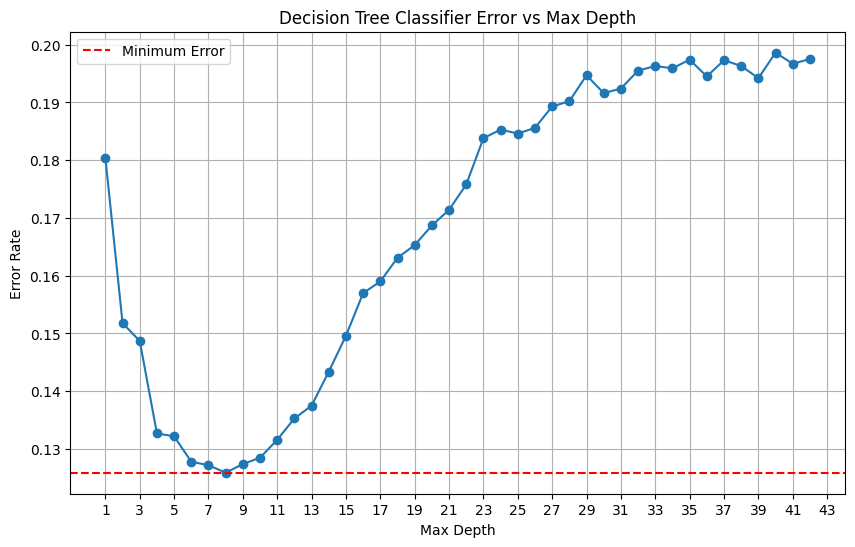

In [225]:
plt.figure(figsize=(10,6))
plt.plot(errors_df['max_depth'], errors_df['error'], marker='o')
plt.title('Decision Tree Classifier Error vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Error Rate')
plt.xticks(np.arange(1, 44, 2))
plt.axhline(y=errors_df['error'].min(), color='r', linestyle='--', label='Minimum Error')
plt.grid()
plt.legend()
plt.show()

In [235]:
def max_features_error(mf):
    model = DecisionTreeClassifier(max_features=mf, max_depth=8, random_state=42)
    model.fit(X_train_final, y_train)
    error = 1 - model.score(X_test_final, y_test)
    return {'max_features': mf, 'error': error}

In [236]:
features_error_df = pd.DataFrame([max_features_error(mf) for mf in range(1, len(input_cols_final)+1)])
features_error_df.head()

,max_features,error
0,1,0.1745
1,2,0.1616
2,3,0.1575
3,4,0.1309
4,5,0.1657


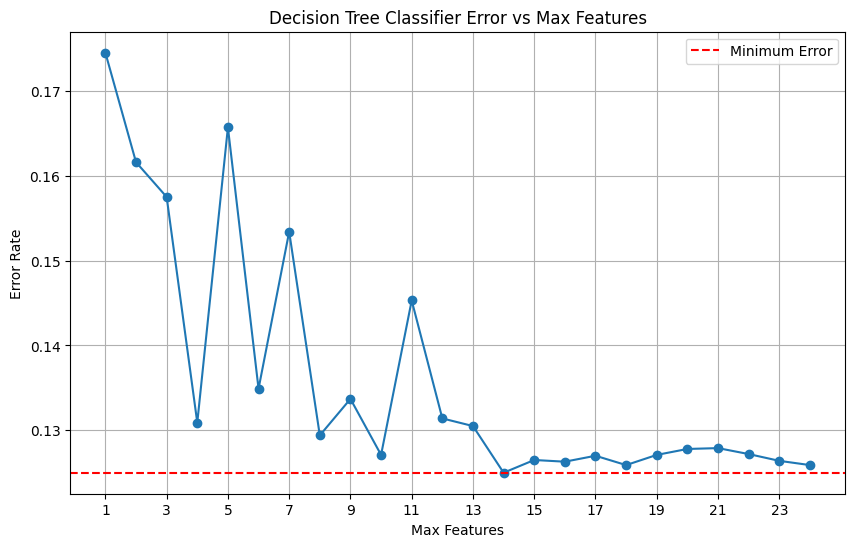

In [237]:
plt.figure(figsize=(10,6))
plt.plot(features_error_df['max_features'], features_error_df['error'], marker='o')
plt.title('Decision Tree Classifier Error vs Max Features')
plt.xlabel('Max Features')
plt.ylabel('Error Rate')
plt.xticks(np.arange(1, len(input_cols_final)+1, 2))
plt.axhline(y=features_error_df['error'].min(), color='r', linestyle='--', label='Minimum Error')
plt.grid()
plt.legend()
plt.show()

In [242]:
def max_leaf_nodes_error(mln):
    model = DecisionTreeClassifier(max_leaf_nodes=2**mln, max_depth=8, max_features=14, random_state=42)
    model.fit(X_train_final, y_train)
    error = 1 - model.score(X_test_final, y_test)
    return {'max_leaf_nodes': mln, 'error': error}

In [243]:
leaf_node_error_df = pd.DataFrame([max_leaf_nodes_error(mln) for mln in range(2, 12)])
leaf_node_error_df.head()

,max_leaf_nodes,error
0,2,0.1487
1,3,0.1486
2,4,0.1303
3,5,0.1274
4,6,0.1276


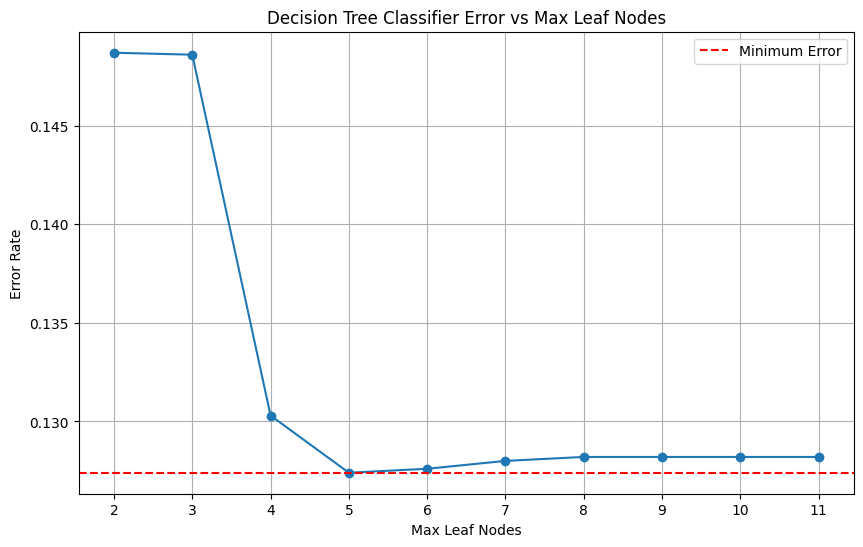

In [244]:
plt.figure(figsize=(10,6))
plt.plot(leaf_node_error_df['max_leaf_nodes'], leaf_node_error_df['error'], marker='o')
plt.title('Decision Tree Classifier Error vs Max Leaf Nodes')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('Error Rate')
plt.xticks(np.arange(2, 12, 1))
plt.axhline(y=leaf_node_error_df['error'].min(), color='r', linestyle='--', label='Minimum Error')
plt.grid()
plt.legend()
plt.show()

In [245]:
# we get the minimum error at max_depth = 8
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=400, n_jobs=-1,max_depth=8, max_features=14, max_leaf_nodes=2**5,random_state=42)
model.fit(X_train_final, y_train)
model.score(X_test_final, y_test)

0.8732

In [248]:
feature_importance = pd.DataFrame({'feature': input_cols_final,
                               'importance': model.feature_importances_})
feature_importance.sort_values(by='importance', ascending=False).head(10)

,feature,importance
16,bmi_to_age_ratio,0.910507
21,smoking_status_Current,0.072890
9,insulin_level,0.011095
6,bmi,0.003253
17,bmi_cholesterol_ratio,0.000951
12,diet_score,0.000578
22,smoking_status_Former,0.000293
20,gender_Other,0.000142
14,hdl_ldl_ratio,0.000077
19,gender_Male,0.000055


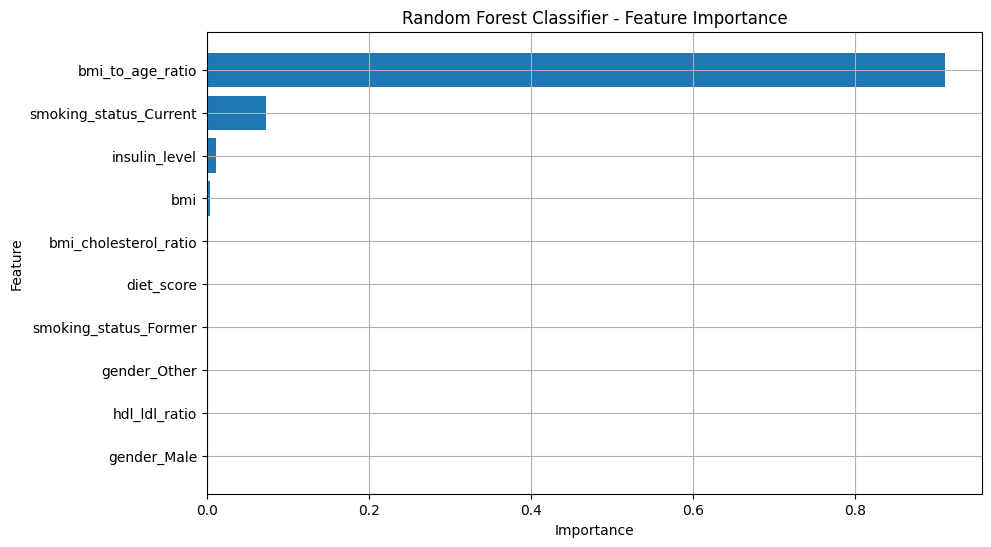

In [249]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance.sort_values(by='importance', ascending=True).tail(10)['feature'],
            feature_importance.sort_values(by='importance', ascending=True).tail(10)['importance'])
plt.title('Random Forest Classifier - Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid()
plt.show()

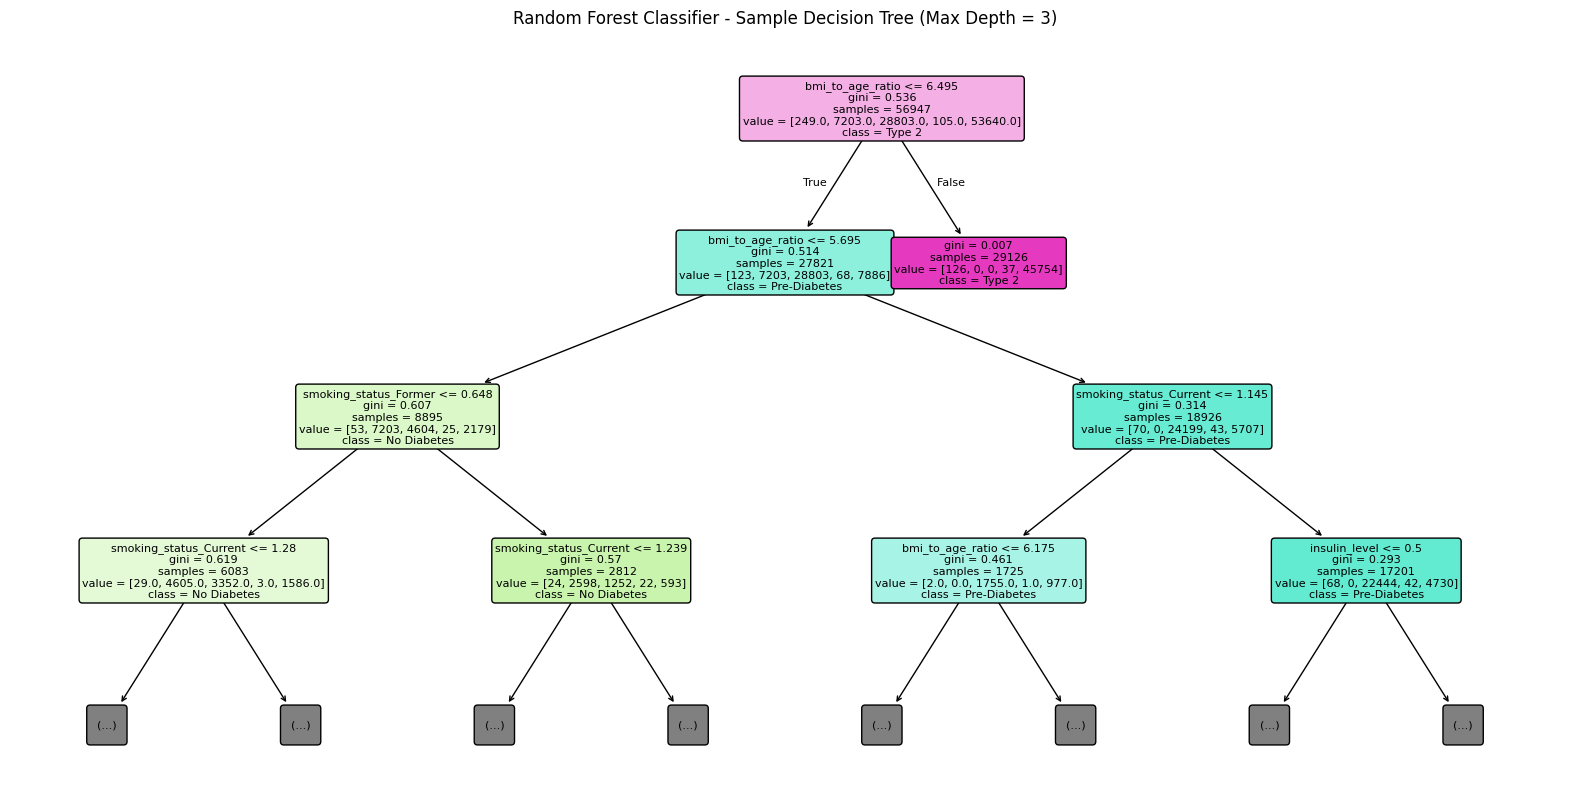

In [250]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0],
          feature_names=input_cols_final,
          class_names=model.classes_,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3
          )
plt.title('Random Forest Classifier - Sample Decision Tree (Max Depth = 3)')
plt.show()

In [251]:
model.classes_

array(['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2'],
      dtype=object)

In [263]:
def preprocess_and_predict(input_dict, model, encoder=None):
    """
    Preprocess user input and predict diabetes risk using a trained model.

    Parameters:
    -----------
    input_dict : dict
        Dictionary containing input feature values.
    model : trained ML model
        Your already-trained model with a `.predict()` method.
    encoder : optional (sklearn LabelEncoder)
        If your model output is label-encoded, this can convert predictions back to labels.

    Returns:
    --------
    DataFrame (processed input) and prediction result.
    """
    df = pd.DataFrame([input_dict])

    df["glucose_after_eating_to_fasting_ratio"] = df["glucose_postprandial"] / df["glucose_fasting"]
    df["bmi_to_age_ratio"] = df["bmi"] / df["age"]
    df["hdl_ldl_ratio"] = df["hdl_cholesterol"] / df["ldl_cholesterol"]
    df["systolic_diastolic_ratio"] = df["systolic_bp"] / df["diastolic_bp"]
    df["bmi_cholesterol_ratio"] = df["bmi"] / df["cholesterol_total"]

    df.drop(columns=[
        "systolic_bp", "diastolic_bp", 
        "hdl_cholesterol", "ldl_cholesterol",
        "glucose_fasting", "glucose_postprandial"
    ], inplace=True)

    categorical_cols = ["gender", "smoking_status"]
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    model_features = model.feature_names_in_ if hasattr(model, "feature_names_in_") else df_encoded.columns
    for col in model_features:
        if col not in df_encoded.columns:
            df_encoded[col] = 0  # add missing columns with 0

    df_encoded = df_encoded[model_features]

    prediction = model.predict_proba(df_encoded)[0]

    if encoder is not None:
        prediction = encoder.inverse_transform([prediction])[0]

    predictions = {'Gestational': prediction[0]*100, 'No Diabetes': prediction[1]*100, 'Prediabetes': prediction[2]*100, 'Type 1 Diabetes': prediction[3]*100, 'Type 2 Diabetes': prediction[4]*100}
    predictions_df = pd.DataFrame([predictions])
    return predictions_df


In [264]:
sample_input = {
    'age': 55,
    'gender': 'Male',
    'smoking_status': 'Former',
    'alcohol_consumption_per_week': 2,
    'physical_activity_minutes_per_week': 150,
    'diet_score': 7.2,
    'sleep_hours_per_day': 7,
    'family_history_diabetes': 1,
    'hypertension_history': 0,
    'cardiovascular_history': 0,
    'bmi': 28.5,
    'systolic_bp': 135,
    'diastolic_bp': 85,
    'cholesterol_total': 190,
    'hdl_cholesterol': 45,
    'ldl_cholesterol': 110,
    'triglycerides': 150,
    'glucose_fasting': 120,
    'glucose_postprandial': 200,
    'insulin_level': 8.4,
    'hba1c': 4.1
}

preprocess_and_predict(sample_input, model)

,Gestational,No Diabetes,Prediabetes,Type 1 Diabetes,Type 2 Diabetes
0,0.43534,60.809411,17.27493,0.112869,21.36745
